In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
DATASET_ROOT = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")
IQ_DIR = DATASET_ROOT / "IQ"

first_iq = sorted(IQ_DIR.iterdir())[0]

print("IQ dosyası:", first_iq.name)

IQ dosyası: Combined_LTE_DSSS_frame_1


In [6]:
with open(first_iq, "rb") as file:
    header = file.read(8)
    raw_data = np.fromfile(file, dtype=np.float32)

value_1, num_samples = np.frombuffer(header, dtype="<u4")

I = raw_data[0::2]
Q = raw_data[1::2]

iq = I + 1j * Q

print("Header value 1:", value_1)
print("Header sample count:", num_samples)
print("IQ samples:", len(iq))


Header value 1: 2
Header sample count: 614400
IQ samples: 614400


In [7]:
metadata_dir = DATASET_ROOT / "Metadata"

metadata_file = metadata_dir / f"{first_iq.name}.csv"

df = pd.read_csv(metadata_file)

sample_rate = float(df["LTE_SR"].iloc[0])

print("Sample rate:", sample_rate, "Hz")
print("Sample rate:", sample_rate / 1e6, "MHz")

Sample rate: 7680000.0 Hz
Sample rate: 7.68 MHz


In [8]:
N = 4096

iq_segment = iq[:N]

fft_result = np.fft.fft(iq_segment)
fft_shifted = np.fft.fftshift(fft_result)

freq = np.fft.fftshift(
    np.fft.fftfreq(N, d=1 / sample_rate)
)

print("FFT size:", N)
print("Frequency resolution:", sample_rate / N, "Hz")
print("Frequency resolution:", sample_rate / N / 1e3, "kHz")

FFT size: 4096
Frequency resolution: 1875.0 Hz
Frequency resolution: 1.875 kHz


In [9]:
magnitude = np.abs(fft_shifted)

print("Magnitude min:", np.min(magnitude))
print("Magnitude max:", np.max(magnitude))

Magnitude min: 2.1713843
Magnitude max: 586.5775


In [10]:

magnitude_db = 20 * np.log10(magnitude + 1e-12)

print("dB min:", np.min(magnitude_db))
print("dB max:", np.max(magnitude_db))

dB min: 6.734734
dB max: 55.36651


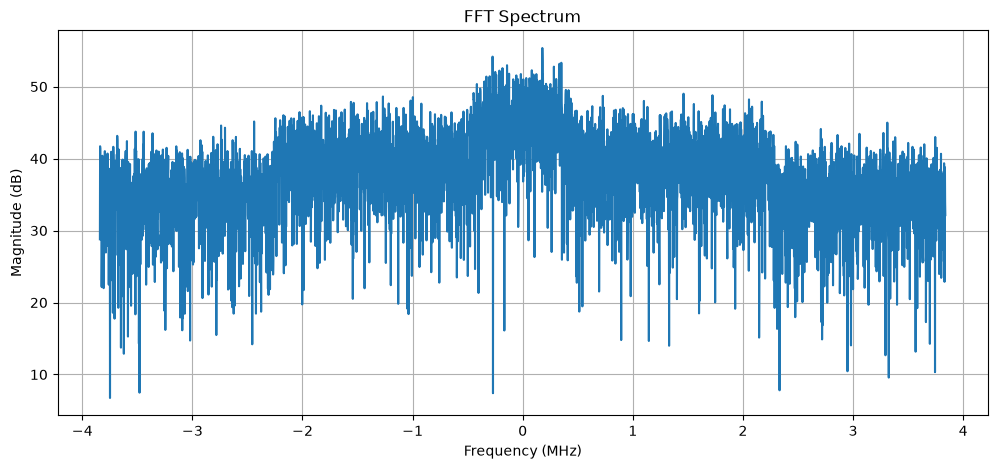

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(freq / 1e6, magnitude_db)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT Spectrum")
plt.grid()

plt.show()

In [12]:
peak_index = np.argmax(magnitude)

peak_frequency = freq[peak_index]
peak_magnitude = magnitude_db[peak_index]

print("Peak frequency:", peak_frequency, "Hz")
print("Peak frequency:", peak_frequency / 1e6, "MHz")
print("Peak magnitude:", peak_magnitude, "dB")

Peak frequency: 178125.0 Hz
Peak frequency: 0.178125 MHz
Peak magnitude: 55.36651 dB


In [13]:
positive_mask = freq > 0
negative_mask = freq < 0

positive_peak = np.max(magnitude[positive_mask])
negative_peak = np.max(magnitude[negative_mask])

print("Positive peak:", positive_peak)
print("Negative peak:", negative_peak)
print("Positive/Negative difference (dB):",
      20 * np.log10(positive_peak / negative_peak))

Positive peak: 586.5775
Negative peak: 510.93314
Positive/Negative difference (dB): 1.1992265


In [14]:
window = np.hanning(N)

iq_windowed = iq_segment * window

fft_windowed = np.fft.fftshift(
    np.fft.fft(iq_windowed)
)

magnitude_windowed = np.abs(fft_windowed)
magnitude_windowed_db = 20 * np.log10(magnitude_windowed + 1e-12)

print("Window:", "Hann")
print("Windowed peak:", np.max(magnitude_windowed_db), "dB")

Window: Hann
Windowed peak: 49.49500908067704 dB


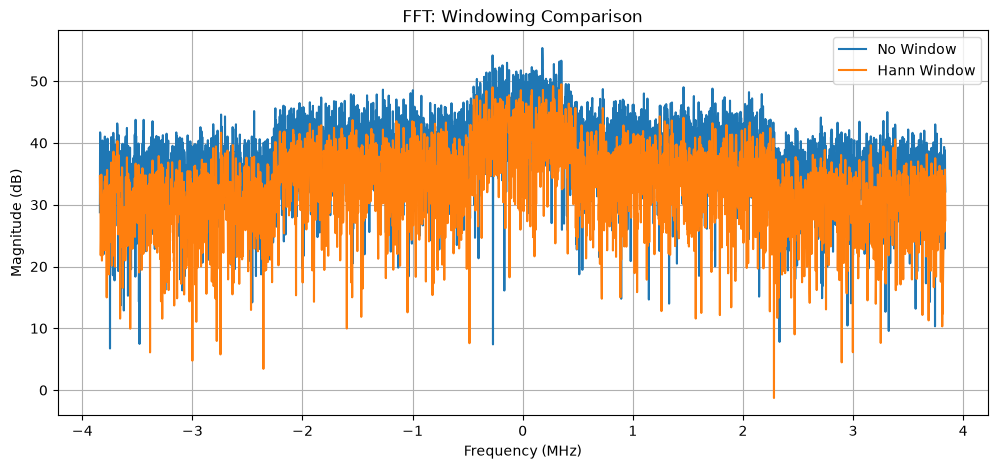

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    freq / 1e6,
    magnitude_db,
    label="No Window"
)

plt.plot(
    freq / 1e6,
    magnitude_windowed_db,
    label="Hann Window"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT: Windowing Comparison")
plt.legend()
plt.grid()

plt.show()

In [16]:
peak_index_no_window = np.argmax(magnitude)
peak_index_hann = np.argmax(magnitude_windowed)

print("No window peak frequency:",
      freq[peak_index_no_window] / 1e3, "kHz")

print("Hann peak frequency:",
      freq[peak_index_hann] / 1e3, "kHz")

print("No window peak:",
      magnitude_db[peak_index_no_window], "dB")

print("Hann peak:",
      magnitude_windowed_db[peak_index_hann], "dB")

No window peak frequency: 178.125 kHz
Hann peak frequency: 350.625 kHz
No window peak: 55.36651 dB
Hann peak: 49.49500908067704 dB


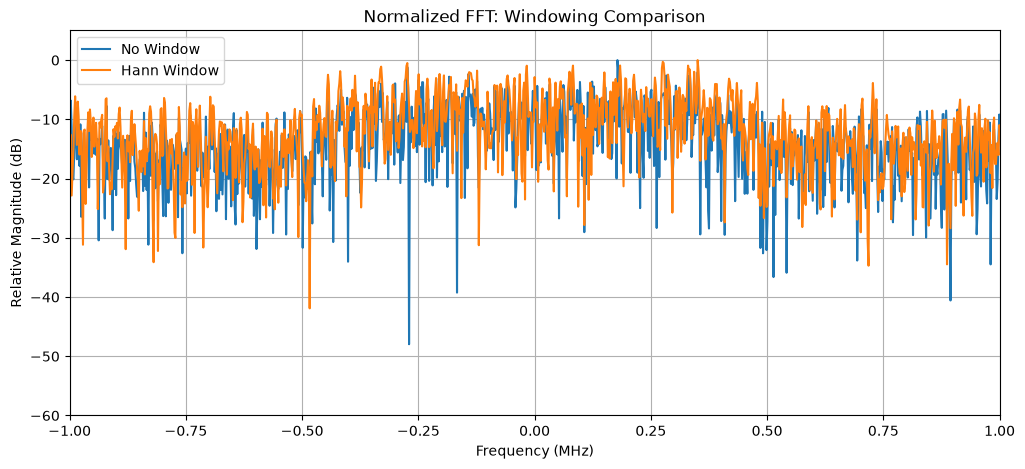

In [17]:
no_window_norm = magnitude_db - np.max(magnitude_db)
hann_norm = magnitude_windowed_db - np.max(magnitude_windowed_db)

plt.figure(figsize=(12, 5))

plt.plot(
    freq / 1e6,
    no_window_norm,
    label="No Window"
)

plt.plot(
    freq / 1e6,
    hann_norm,
    label="Hann Window"
)

plt.xlim(-1, 1)
plt.ylim(-60, 5)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Magnitude (dB)")
plt.title("Normalized FFT: Windowing Comparison")
plt.legend()
plt.grid()

plt.show()

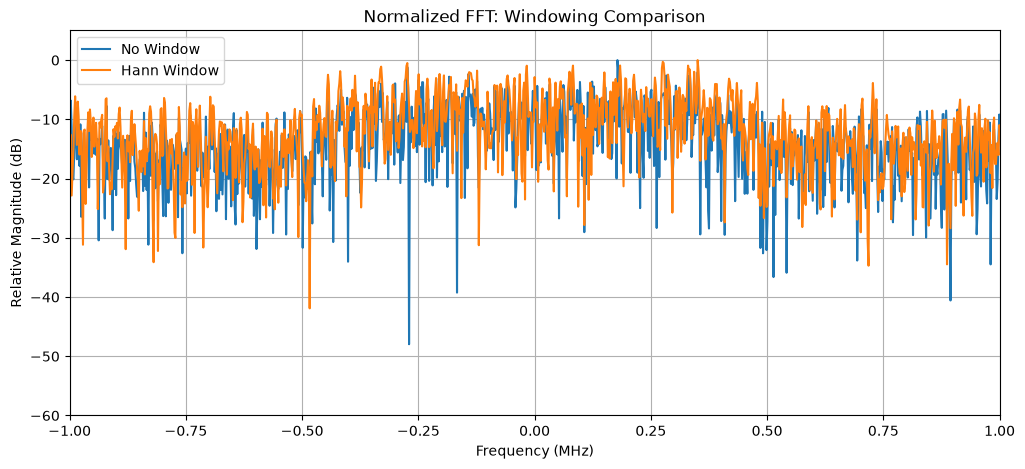

In [18]:
no_window_norm = magnitude_db - np.max(magnitude_db)
hann_norm = magnitude_windowed_db - np.max(magnitude_windowed_db)

plt.figure(figsize=(12, 5))

plt.plot(freq / 1e6, no_window_norm, label="No Window")
plt.plot(freq / 1e6, hann_norm, label="Hann Window")

plt.xlim(-1, 1)
plt.ylim(-60, 5)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Magnitude (dB)")
plt.title("Normalized FFT: Windowing Comparison")
plt.legend()
plt.grid()

plt.show()

In [19]:
main_peak = np.max(magnitude)
hann_peak = np.max(magnitude_windowed)

print("No Window peak:", main_peak)
print("Hann peak:", hann_peak)

print(
    "Peak difference (dB):",
    20 * np.log10(hann_peak / main_peak)
)

No Window peak: 586.5775
Hann peak: 298.3667708353816
Peak difference (dB): -5.871499141266795


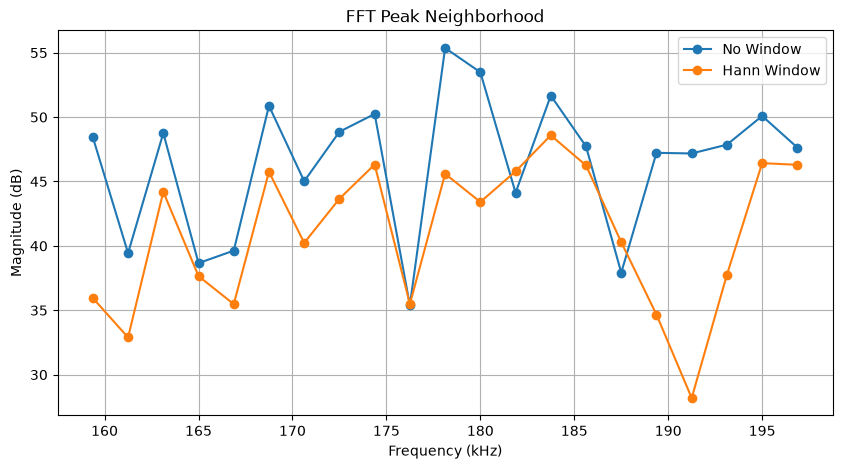

In [20]:
peak_idx = np.argmax(magnitude)

left = max(0, peak_idx - 10)
right = min(len(magnitude), peak_idx + 11)

plt.figure(figsize=(10, 5))

plt.plot(
    freq[left:right] / 1e3,
    magnitude_db[left:right],
    marker="o",
    label="No Window"
)

plt.plot(
    freq[left:right] / 1e3,
    magnitude_windowed_db[left:right],
    marker="o",
    label="Hann Window"
)

plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT Peak Neighborhood")
plt.legend()
plt.grid()

plt.show()

In [21]:
print("Sample rate:", sample_rate, "Hz")
print("FFT size:", N)
print("Frequency resolution:", sample_rate / N, "Hz")

Sample rate: 7680000.0 Hz
FFT size: 4096
Frequency resolution: 1875.0 Hz


In [22]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures directory:", FIGURES_DIR.resolve())

Figures directory: C:\Users\asus\Desktop\RF-Anomaly-Detection\outputs\figures


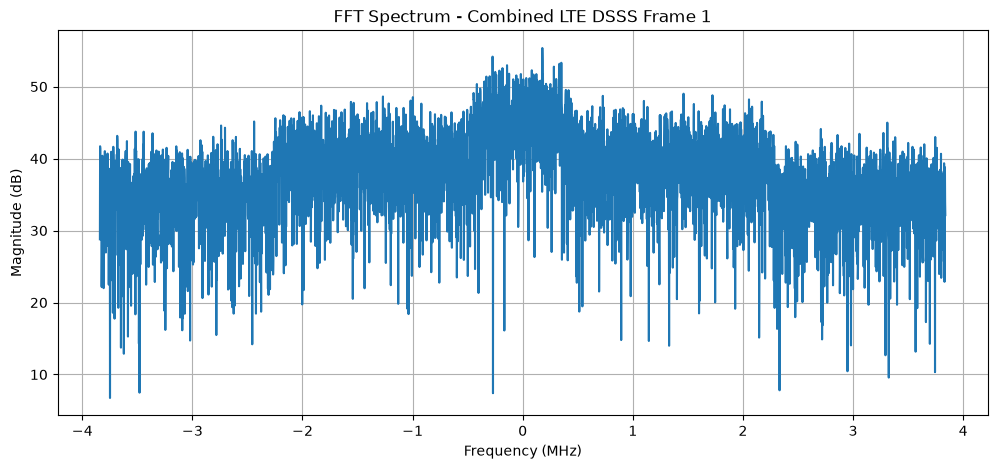

Saved: C:\Users\asus\Desktop\RF-Anomaly-Detection\outputs\figures\frame_1_fft_spectrum.png


In [23]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))

plt.plot(freq / 1e6, magnitude_db)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT Spectrum - Combined LTE DSSS Frame 1")
plt.grid()

output_path = FIGURES_DIR / "frame_1_fft_spectrum.png"

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", output_path.resolve())